In [1]:
# Setup: import required libraries and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from IPython.display import display

np.random.seed(42)
sns.set_theme(style="whitegrid")

df = pd.read_csv('final.csv')

# Keep only expected columns in case there are accidental extra columns in the CSV
required_cols = ['Year_Week', 'year', 'week', 'retail_market', 'vegetable_type', 'retail_price']
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

df = df[required_cols].copy()
df['retail_price'] = pd.to_numeric(df['retail_price'], errors='coerce')

print('Data shape:', df.shape)
print('Markets available:', sorted(df['retail_market'].dropna().unique())[:10], '...')
print('Vegetable count:', df['vegetable_type'].nunique())

Data shape: (61152, 6)
Markets available: ['Anuradhapura', 'Badulla', 'Colombo', 'Dambulla', 'Embilipitiya', 'Hambanthota', 'Kaluthara', 'Kandy', 'Kurunegala', 'Mathara'] ...
Vegetable count: 12


## Step 1 — Filter and prepare the data

In this step, we keep only Colombo and Meegoda rows, pivot them into side-by-side columns, and remove missing price pairs so both values are always present for each week-vegetable point.

In [2]:
# Filter to the two markets
pair_df = df[df['retail_market'].isin(['Colombo', 'Meegoda'])].copy()

# Build numeric week for ordering (week values are like 'w1', 'w2', ...)
pair_df['week_num'] = pair_df['week'].astype(str).str.extract(r'(\d+)').astype(float)

# Pivot so each row is (Year_Week, vegetable_type) with Colombo and Meegoda prices
market_pairs = pair_df.pivot_table(
    index=['Year_Week', 'vegetable_type', 'year', 'week_num'],
    columns='retail_market',
    values='retail_price',
    aggfunc='mean'
).reset_index()

# Ensure both columns exist even if one market is absent in part of the data
for col in ['Colombo', 'Meegoda']:
    if col not in market_pairs.columns:
        market_pairs[col] = np.nan

# Drop rows where either market has missing price
market_pairs_clean = market_pairs.dropna(subset=['Colombo', 'Meegoda']).copy()
market_pairs_clean = market_pairs_clean.sort_values(['year', 'week_num', 'vegetable_type']).reset_index(drop=True)

print('Filtered rows (raw two-market data):', len(pair_df))
print('Paired rows after pivot + dropna:', len(market_pairs_clean))
display(market_pairs_clean.head())

Filtered rows (raw two-market data): 8736
Paired rows after pivot + dropna: 4368


retail_market,Year_Week,vegetable_type,year,week_num,Colombo,Meegoda
0,2013-w1,ASH PLANTAINS,2013,1.0,111.35,92.5
1,2013-w1,BEETROOT,2013,1.0,155.00,132.0
2,2013-w1,BRINJALS,2013,1.0,151.79,135.0
3,2013-w1,CABBAGE,2013,1.0,115.00,88.0
4,2013-w1,CARROT,2013,1.0,173.66,156.0


## Step 2 — Calculate the r value

Now we compute Pearson correlation r between Colombo and Meegoda prices over all paired observations. This tells us how strongly the two markets move together in a linear way.

In [3]:
overall_r, overall_p = pearsonr(market_pairs_clean['Colombo'], market_pairs_clean['Meegoda'])

def interpret_r(r):
    a = abs(r)
    if a >= 0.8:
        strength = 'very strong'
    elif a >= 0.6:
        strength = 'strong'
    elif a >= 0.4:
        strength = 'moderate'
    elif a >= 0.2:
        strength = 'weak'
    else:
        strength = 'very weak'

    direction = 'positive' if r >= 0 else 'negative'
    return f'{strength} {direction} linear relationship'

print(f'Pearson r (Colombo vs Meegoda): {overall_r:.4f}')
print('Interpretation:', interpret_r(overall_r))
print(f'p-value: {overall_p:.4g}')

Pearson r (Colombo vs Meegoda): 0.9736
Interpretation: very strong positive linear relationship
p-value: 0


## Step 3 — Scatter plot

This scatter plot compares Colombo (x-axis) and Meegoda (y-axis) prices point-by-point. The diagonal line represents perfect equality between markets.

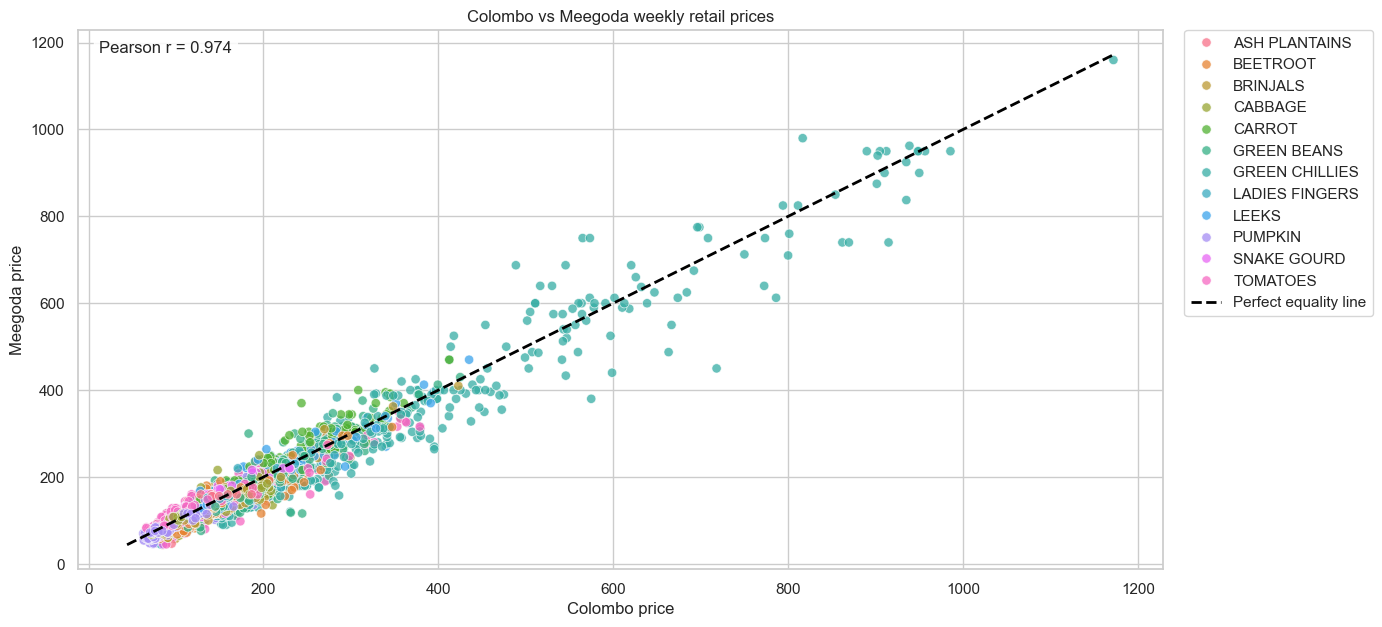

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.scatterplot(
    data=market_pairs_clean,
    x='Colombo',
    y='Meegoda',
    hue='vegetable_type',
    alpha=0.75,
    s=45,
    ax=ax
)

min_val = float(np.nanmin([market_pairs_clean['Colombo'].min(), market_pairs_clean['Meegoda'].min()]))
max_val = float(np.nanmax([market_pairs_clean['Colombo'].max(), market_pairs_clean['Meegoda'].max()]))
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2, color='black', label='Perfect equality line')

ax.set_title('Colombo vs Meegoda weekly retail prices')
ax.set_xlabel('Colombo price')
ax.set_ylabel('Meegoda price')
ax.text(
    0.02, 0.98,
    f'Pearson r = {overall_r:.3f}',
    transform=ax.transAxes,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

display(fig)
plt.close(fig)

## Step 4 — Weekly price movement line chart

Here we track prices over time for **TOMATOES**, **GREEN CHILLIES**, and **CARROT**. Each subplot compares Colombo and Meegoda week-by-week to show whether their movements are similar.

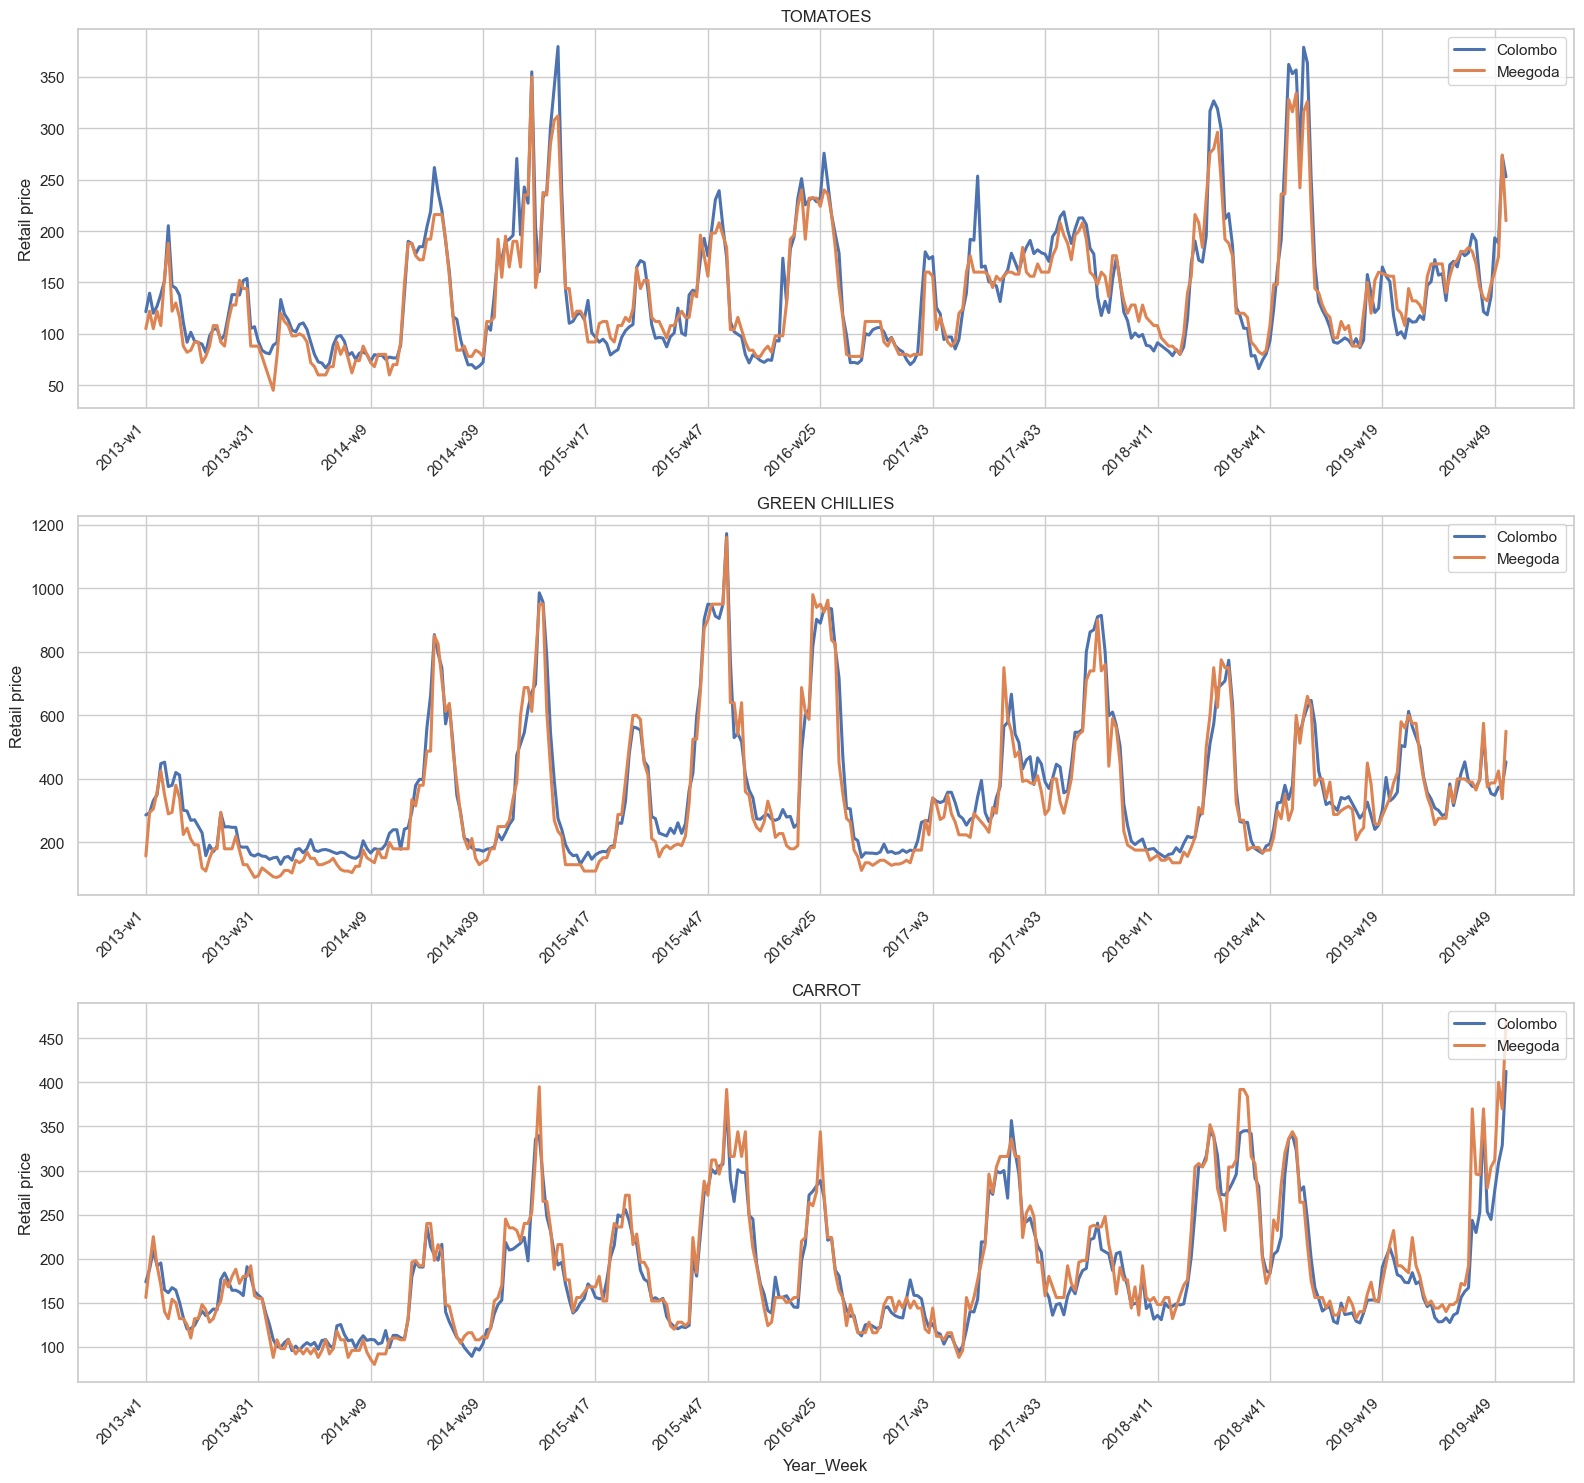

In [5]:
chosen_vegetables = ['TOMATOES', 'GREEN CHILLIES', 'CARROT']

plot_df = market_pairs_clean.sort_values(['year', 'week_num', 'vegetable_type']).copy()
fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=False)

for i, veg in enumerate(chosen_vegetables):
    ax = axes[i]
    sub = plot_df[plot_df['vegetable_type'] == veg].copy()

    if sub.empty:
        ax.text(0.5, 0.5, f'{veg}: no data found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(veg)
        continue

    sub = sub.sort_values(['year', 'week_num'])
    x = np.arange(len(sub))

    ax.plot(x, sub['Colombo'].values, label='Colombo', linewidth=2.2)
    ax.plot(x, sub['Meegoda'].values, label='Meegoda', linewidth=2.2)
    ax.set_title(veg)
    ax.set_ylabel('Retail price')
    ax.legend(loc='upper right')

    tick_step = max(1, len(sub) // 12)
    tick_idx = x[::tick_step]
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(sub['Year_Week'].iloc[::tick_step], rotation=45, ha='right')

axes[-1].set_xlabel('Year_Week')
fig.tight_layout()
display(fig)
plt.close(fig)

## Step 5 — Per-vegetable correlation table

Next, we compute Pearson correlation separately for each vegetable and sort results from highest to lowest. Then we visualize the ranking in a horizontal bar chart.

Per-vegetable Pearson correlations (sorted):


,vegetable_type,r,p_value,n_pairs
0,LEEKS,0.973603,2.389020e-234,364
1,GREEN CHILLIES,0.969311,1.122092e-222,364
2,CARROT,0.967668,1.214503e-218,364
3,TOMATOES,0.957253,4.194751e-197,364
4,BRINJALS,0.953690,5.946213e-191,364
5,BEETROOT,0.952412,7.317047e-189,364
6,PUMPKIN,0.946516,6.466865e-180,364
7,CABBAGE,0.944783,1.770629e-177,364
8,SNAKE GOURD,0.936968,2.186716e-167,364
9,GREEN BEANS,0.931258,8.452174e-161,364


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17036\856872648.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=veg_corr, x='r', y='vegetable_type', palette='viridis', ax=ax)


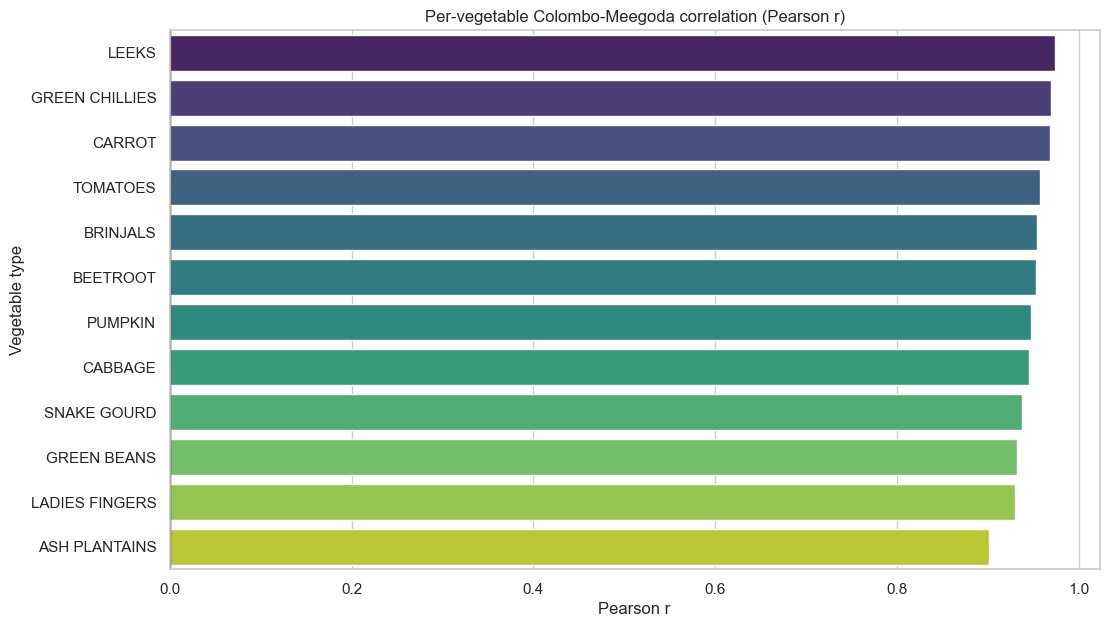

In [6]:
corr_rows = []
for veg, sub in market_pairs_clean.groupby('vegetable_type'):
    if len(sub) >= 2 and sub['Colombo'].nunique() > 1 and sub['Meegoda'].nunique() > 1:
        r, p = pearsonr(sub['Colombo'], sub['Meegoda'])
    else:
        r, p = np.nan, np.nan
    corr_rows.append({
        'vegetable_type': veg,
        'r': r,
        'p_value': p,
        'n_pairs': len(sub)
    })

veg_corr = pd.DataFrame(corr_rows).sort_values('r', ascending=False).reset_index(drop=True)
print('Per-vegetable Pearson correlations (sorted):')
display(veg_corr)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=veg_corr, x='r', y='vegetable_type', palette='viridis', ax=ax)
ax.set_title('Per-vegetable Colombo-Meegoda correlation (Pearson r)')
ax.set_xlabel('Pearson r')
ax.set_ylabel('Vegetable type')
ax.axvline(0, color='black', linewidth=1)
display(fig)
plt.close(fig)

## Step 6 — Multicollinearity problem demonstration

This step compares two linear regression models for predicting `retail_price`:
1. using **both** Colombo and Meegoda prices as features, and
2. using **only** Colombo price.

Because Colombo and Meegoda are usually highly correlated, including both can create multicollinearity (overlapping information), which can make coefficients unstable even when model fit ($R^2$) changes only a little.

In [9]:
# Build a target table: each paired row creates two target rows (one per market)
reg_base = market_pairs_clean[['Year_Week', 'vegetable_type', 'Colombo', 'Meegoda']].copy()
reg_long = reg_base.melt(
    id_vars=['Year_Week', 'vegetable_type', 'Colombo', 'Meegoda'],
    value_vars=['Colombo', 'Meegoda'],
    var_name='target_market',
    value_name='retail_price'
).dropna().copy()

X_both = reg_long[['Colombo', 'Meegoda']].values
X_colombo_only = reg_long[['Colombo']].values
y = reg_long['retail_price'].values

if len(reg_long) == 0:
    print("No data available for regression modeling. Please check your data preparation steps.")
else:
    model_both = LinearRegression()
    model_both.fit(X_both, y)
    pred_both = model_both.predict(X_both)
    r2_both = r2_score(y, pred_both)

    model_colombo = LinearRegression()
    model_colombo.fit(X_colombo_only, y)
    pred_colombo = model_colombo.predict(X_colombo_only)
    r2_colombo = r2_score(y, pred_colombo)

    print('Model A (features: Colombo + Meegoda)')
    print(f'  R^2: {r2_both:.4f}')
    print(f'  Intercept: {model_both.intercept_:.4f}')
    print(f'  Coefficients: Colombo={model_both.coef_[0]:.4f}, Meegoda={model_both.coef_[1]:.4f}')

    print('\nModel B (feature: Colombo only)')
    print(f'  R^2: {r2_colombo:.4f}')
    print(f'  Intercept: {model_colombo.intercept_:.4f}')
    print(f'  Coefficient: Colombo={model_colombo.coef_[0]:.4f}')

    print('\nFeature correlation (Colombo vs Meegoda):', f'{np.corrcoef(reg_long["Colombo"], reg_long["Meegoda"])[0,1]:.4f}')

No data available for regression modeling. Please check your data preparation steps.


### What this says about multicollinearity

If the two-feature model and one-feature model have similar $R^2$, it means the second feature (Meegoda) may be adding information that is partly redundant with Colombo.

When predictors are strongly correlated, coefficient values can become sensitive and harder to interpret causally. In practice, this is the multicollinearity issue: prediction may still look okay, but coefficient interpretation becomes less reliable.

## Step 7 — Lag feature demonstration

Finally, we create a lagged feature (`meegoda_price_last_week`) per vegetable, then compare its correlation with current Colombo price against the original same-week correlation.

We also plot this week’s Meegoda price against next week’s Colombo price to inspect delayed co-movement.

Original same-week r (Colombo vs Meegoda): 0.9736
Lagged r (Colombo current vs Meegoda last week): 0.9521
Difference (lagged - original): -0.0215
Lagged p-value: 0


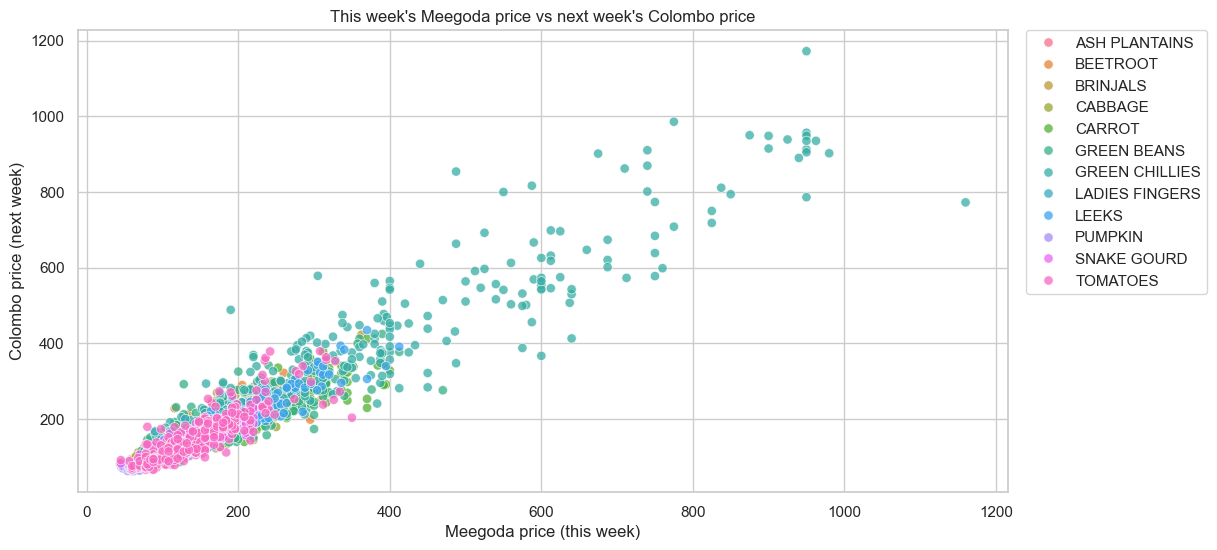

In [10]:
lag_df = market_pairs_clean[['Year_Week', 'vegetable_type', 'year', 'week_num', 'Colombo', 'Meegoda']].copy()
lag_df = lag_df.sort_values(['vegetable_type', 'year', 'week_num']).reset_index(drop=True)

# Last week's Meegoda price (per vegetable)
lag_df['meegoda_price_last_week'] = lag_df.groupby('vegetable_type')['Meegoda'].shift(1)

valid_lag = lag_df.dropna(subset=['meegoda_price_last_week', 'Colombo']).copy()
lag_r, lag_p = pearsonr(valid_lag['meegoda_price_last_week'], valid_lag['Colombo'])

print(f'Original same-week r (Colombo vs Meegoda): {overall_r:.4f}')
print(f'Lagged r (Colombo current vs Meegoda last week): {lag_r:.4f}')
print(f'Difference (lagged - original): {lag_r - overall_r:.4f}')
print(f'Lagged p-value: {lag_p:.4g}')

# This week's Meegoda vs next week's Colombo
lead_df = lag_df.copy()
lead_df['colombo_price_next_week'] = lead_df.groupby('vegetable_type')['Colombo'].shift(-1)
lead_plot = lead_df.dropna(subset=['Meegoda', 'colombo_price_next_week'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=lead_plot,
    x='Meegoda',
    y='colombo_price_next_week',
    hue='vegetable_type',
    alpha=0.75,
    s=45,
    ax=ax
)
ax.set_title("This week's Meegoda price vs next week's Colombo price")
ax.set_xlabel("Meegoda price (this week)")
ax.set_ylabel("Colombo price (next week)")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
display(fig)
plt.close(fig)